Repeat the simulation as the previous assignment but using Wolff cluster algorithm.

Tasks: Plot the magnetization and energy as the function of $\beta$.

Compare Metropolis and Wolff cluster algorithm.

In [27]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [28]:
# Creates initial configuration with random spins on a 2D lattice
def generate_initial_configuration(N):
    return [[random.choice([-1, 1]) for _ in range(N)] for _ in range(N)]

In [29]:
# Try to add a spin to cluster.
# 1. If the spin is different than the type we create cluster for then it stops.
# 2. If the spin is the same but already in cluster, it stops.
# 3. If the spin is the same and not in cluster, it adds to cluster with probability p_add and checks all neighbors of this spin.
# Recursion stops when all neighbors of the cluster are checked and are either:
#    - different type, or
#    - the same type but already in cluster, or
#    - the same type and not in cluster but not added to cluster.
def try_add_to_cluster(lattice, N, i, j, original_spin, p_add, cluster):
    
    # 1:
    if lattice[i][j] != original_spin:
        return
    
    # 2:
    if (i, j) in cluster:
        return
    
    # 3:
    if random.random() < p_add:
        cluster.add((i, j))
        for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
                try_add_to_cluster(lattice, N, id, jd, original_spin, p_add, cluster)

# Creates a cluster of spins using Wolff algorithm.
# 1. Chooses random seed spin.
# 2. Creates cluster with seed spin already in it.
# 3. Checks all neighbors of the seed spin and tries to add them to the cluster.
def create_cluster(lattice, N, p_add):

    # 1:
    i = random.randint(0, N-1)
    j = random.randint(0, N-1)
    spin = lattice[i][j]

    # 2:
    cluster = {(i, j)}

    # 3:
    for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
        try_add_to_cluster(lattice, N, id, jd, spin, p_add, cluster)

    return cluster

In [30]:
# Computes total energy of the current configuration.
# 1. Sets variable for total energy to 0.
# 2. Loops through all spins in the lattice.
# 3. For each spin, gets the energy of two neighbors: (right, down) and adds it to total energy.
# We calculate only two neighboring spins for each field to avoid double counting.
def compute_total_energy(lattice, N):

    # 1:
    E_total = 0

    # 2:
    for i in range(N):
        for j in range(N):
            spin = lattice[i][j]

            # 3:
            s_right = lattice[i][(j+1) % N]
            s_down = lattice[(i+1) % N][j]

            E_total += -spin * (s_right + s_down)

    return E_total

# Computes magnetization of the current configuration.
# Magnetization is given as the average spin value in the lattice.
def compute_magnetization(lattice):
    return np.mean(lattice)

In [31]:
# Flips all spins in the cluster.
# 1. Calculates probability of adding a spin to the cluster.
# 2. Creates cluster of spins using Wolff algorithm.
# 3. Flips all spins in the cluster.
def flip_cluster(lattice, N, beta):

    # 1:
    p_add = 1.0 - math.exp(-2.0 * beta)

    # 2:
    cluster = create_cluster(lattice, N, p_add)

    # 3:
    for i, j in cluster:
        lattice[i][j] *= -1

In [32]:
# Runs the simulation of the Ising model using Wolff algorithm.
# 1. Creates initial configuration of the lattice.
# 2. Runs burn in phase - don't collect data on steps.
# 3. Runs measurement phase - computes total energy and magnetization after each step.
# 4. Computes mean energy and magnetization.
def simulate(N, beta, burn_in_steps=1000, measure_steps=2000):

    # 1:
    lattice = generate_initial_configuration(N)

    # 2:
    for _ in range(burn_in_steps):
        flip_cluster(lattice, N, beta)

    E = []
    M = []

    # 3:
    for _ in range(measure_steps):
        flip_cluster(lattice, N, beta)

        e = compute_total_energy(lattice, N)
        m = compute_magnetization(lattice)
        E.append(e)
        M.append(abs(m))

    # 4:
    mean_E = sum(E) / len(E)
    mean_M = sum(M) / len(M)

    return E, M, mean_E, mean_M

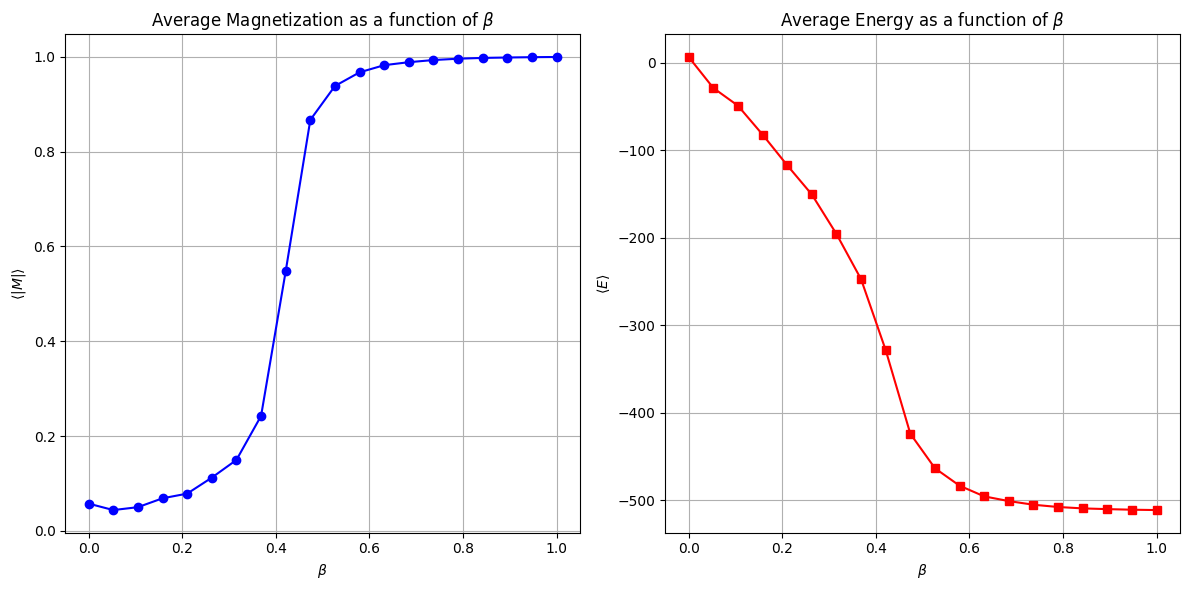

In [33]:
# Visualization of the results :
betas = np.linspace(0.0, 1.0, 20)

mean_Es = []
mean_Ms = []

for beta in betas:
    E, M, mean_E, mean_M = simulate(16, beta)
    mean_Es.append(mean_E)
    mean_Ms.append(mean_M)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# magnetization plot
ax1.plot(betas, mean_Ms, 'o-', color='blue')
ax1.set_title("Average Magnetization as a function of $\\beta$")
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("$\\langle |M| \\rangle$")
ax1.grid()

# energy plot
ax2.plot(betas, mean_Es, 's-', color='red')
ax2.set_title("Average Energy as a function of $\\beta$")
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("$\\langle E \\rangle$")
ax2.grid()

plt.tight_layout()
plt.show()

Wolff's algorithm in my testing works ~2x faster for small lattice (16x16). ~14s instead of ~30s with Metropolis.